In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
# Load the dataset
df = pd.read_csv('FIFA_DATASET.csv')

In [5]:
# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (54600, 75)

Column Names:
['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score',

In [7]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


1.2 Handling Missing Values

In [9]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print("\nMissing Values Analysis:")
print(missing_df[missing_df['Missing Values'] > 0])

# Observations: Many players have 0 minutes played (substitutes)
# Option 1: Remove players with 0 minutes (they didn't play)
df_played = df[df['minutes_played'] > 0].copy()

# Option 2: For players with 0 minutes, keep their stats but note they didn't play
df['is_substitute'] = (df['minutes_played'] == 0).astype(int)

print(f"\nOriginal dataset: {len(df)} players")
print(f"Players with minutes played: {len(df_played)}")
print(f"Substitutes: {len(df) - len(df_played)}")


Missing Values Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []

Original dataset: 54600 players
Players with minutes played: 31558
Substitutes: 23042


1.3 Handling Data Types and Outliers

In [11]:
# Convert date column to datetime
df['match_date'] = pd.to_datetime(df['match_date'])

# Check for duplicates
duplicates = df.duplicated(subset=['player_id', 'match_id']).sum()
print(f"Duplicate records: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    df = df.drop_duplicates(subset=['player_id', 'match_id'])

# Identify and handle outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

Duplicate records: 0


In [12]:
# Check outliers in key numerical columns
numerical_cols = ['age', 'height_cm', 'weight_kg', 'market_value_eur', 
                  'minutes_played', 'goals', 'assists', 'player_rating']

outlier_summary = {}
for col in numerical_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_summary[col] = len(outliers)

print("\nOutlier Counts per Column:")
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

# For market value, extreme values might be valid (star players)
df['market_value_eur_capped'] = df['market_value_eur'].clip(
    lower=df['market_value_eur'].quantile(0.01),
    upper=df['market_value_eur'].quantile(0.99)
)


Outlier Counts per Column:
age: 38 outliers
height_cm: 253 outliers
weight_kg: 282 outliers
market_value_eur: 5254 outliers
minutes_played: 0 outliers
goals: 2743 outliers
assists: 2664 outliers
player_rating: 0 outliers


1.4 Feature Engineering

In [82]:
# Create features

# Create a filtered dataframe for players who actually played
df_played = df[df['minutes_played'] > 0].copy()

# Goals per 90 minutes (only for players with minutes)
df_played['goals_per_90'] = (df_played['goals'] / df_played['minutes_played']) * 90

# Assists per 90 minutes
df_played['assists_per_90'] = (df_played['assists'] / df_played['minutes_played']) * 90

# Goal contribution
df_played['goal_contribution'] = df_played['goals'] + df_played['assists']
df_played['goal_contribution_per_90'] = (df_played['goal_contribution'] / df_played['minutes_played']) * 90

# Defensive contribution index (only for players with minutes)
df_played['defensive_contribution'] = (df_played['tackles'] + df_played['interceptions'] + 
                                       df_played['clearances'] + df_played['blocks']) / df_played['minutes_played'] * 90

# Performance per minute ratio (only for players with minutes)
df_played['rating_per_minute'] = df_played['player_rating'] / df_played['minutes_played'] * 90

# Shot conversion rate – safe for all players (shots replaced with 1 to avoid division by zero)
df['shot_conversion'] = df['shots_on_target'] / df['shots'].replace(0, 1)

# Categorize players by position (for all players)
def categorize_position(position):
    if position in ['Goalkeeper']:
        return 'Goalkeeper'
    elif position in ['Defender']:
        return 'Defender'
    elif position in ['Midfielder']:
        return 'Midfielder'
    else:
        return 'Forward'

df['position_category'] = df['position'].apply(categorize_position)

print("Feature Engineering Complete!")
print("New features added for all players:", ['shot_conversion', 'position_category'])
print("New features added for players with minutes > 0:", 
      ['goals_per_90', 'assists_per_90', 'goal_contribution_per_90', 
       'defensive_contribution', 'rating_per_minute'])

Feature Engineering Complete!
New features added for all players: ['shot_conversion', 'position_category']
New features added for players with minutes > 0: ['goals_per_90', 'assists_per_90', 'goal_contribution_per_90', 'defensive_contribution', 'rating_per_minute']


2.1 Descriptive Statistics

In [83]:
# Summary statistics for key numerical columns
print("Descriptive Statistics for Key Numerical Variables:")
print(df[numerical_cols].describe())

Descriptive Statistics for Key Numerical Variables:
                age     height_cm     weight_kg  market_value_eur  \
count  54600.000000  54600.000000  54600.000000      5.460000e+04   
mean      26.296484    181.654341     75.754853      2.008445e+07   
std        4.067519      6.277792      3.951481      2.718866e+07   
min       17.000000    163.000000     65.000000      5.288220e+05   
25%       23.000000    177.000000     73.000000      4.444778e+06   
50%       26.000000    182.000000     76.000000      1.027111e+07   
75%       29.000000    186.000000     78.000000      2.342013e+07   
max       39.000000    200.000000     87.000000      2.000000e+08   

       minutes_played         goals       assists  player_rating  
count    54600.000000  54600.000000  54600.000000   54600.000000  
mean        36.199817      0.055385      0.052363       3.634700  
std         36.419755      0.251900      0.239021       3.155846  
min          0.000000      0.000000      0.000000       0.

In [84]:
# Statistics by Position
position_stats = df.groupby('position_category')[numerical_cols].mean()
print("\nAverage Statistics by Position:")
print(position_stats.round(2))


Average Statistics by Position:
                     age  height_cm  weight_kg  market_value_eur  \
position_category                                                  
Defender           26.67     183.56      76.41       15380287.61   
Forward            25.53     178.61      74.16       27243386.00   
Goalkeeper         28.67     189.11      78.69       12176579.57   
Midfielder         25.56     178.99      75.11       22972887.84   

                   minutes_played  goals  assists  player_rating  
position_category                                                 
Defender                    37.49   0.02     0.02           3.79  
Forward                     37.64   0.14     0.08           3.88  
Goalkeeper                  25.55   0.00     0.01           2.07  
Midfielder                  37.66   0.05     0.08           3.86  


2.2 Univariate Analysis - Distributions

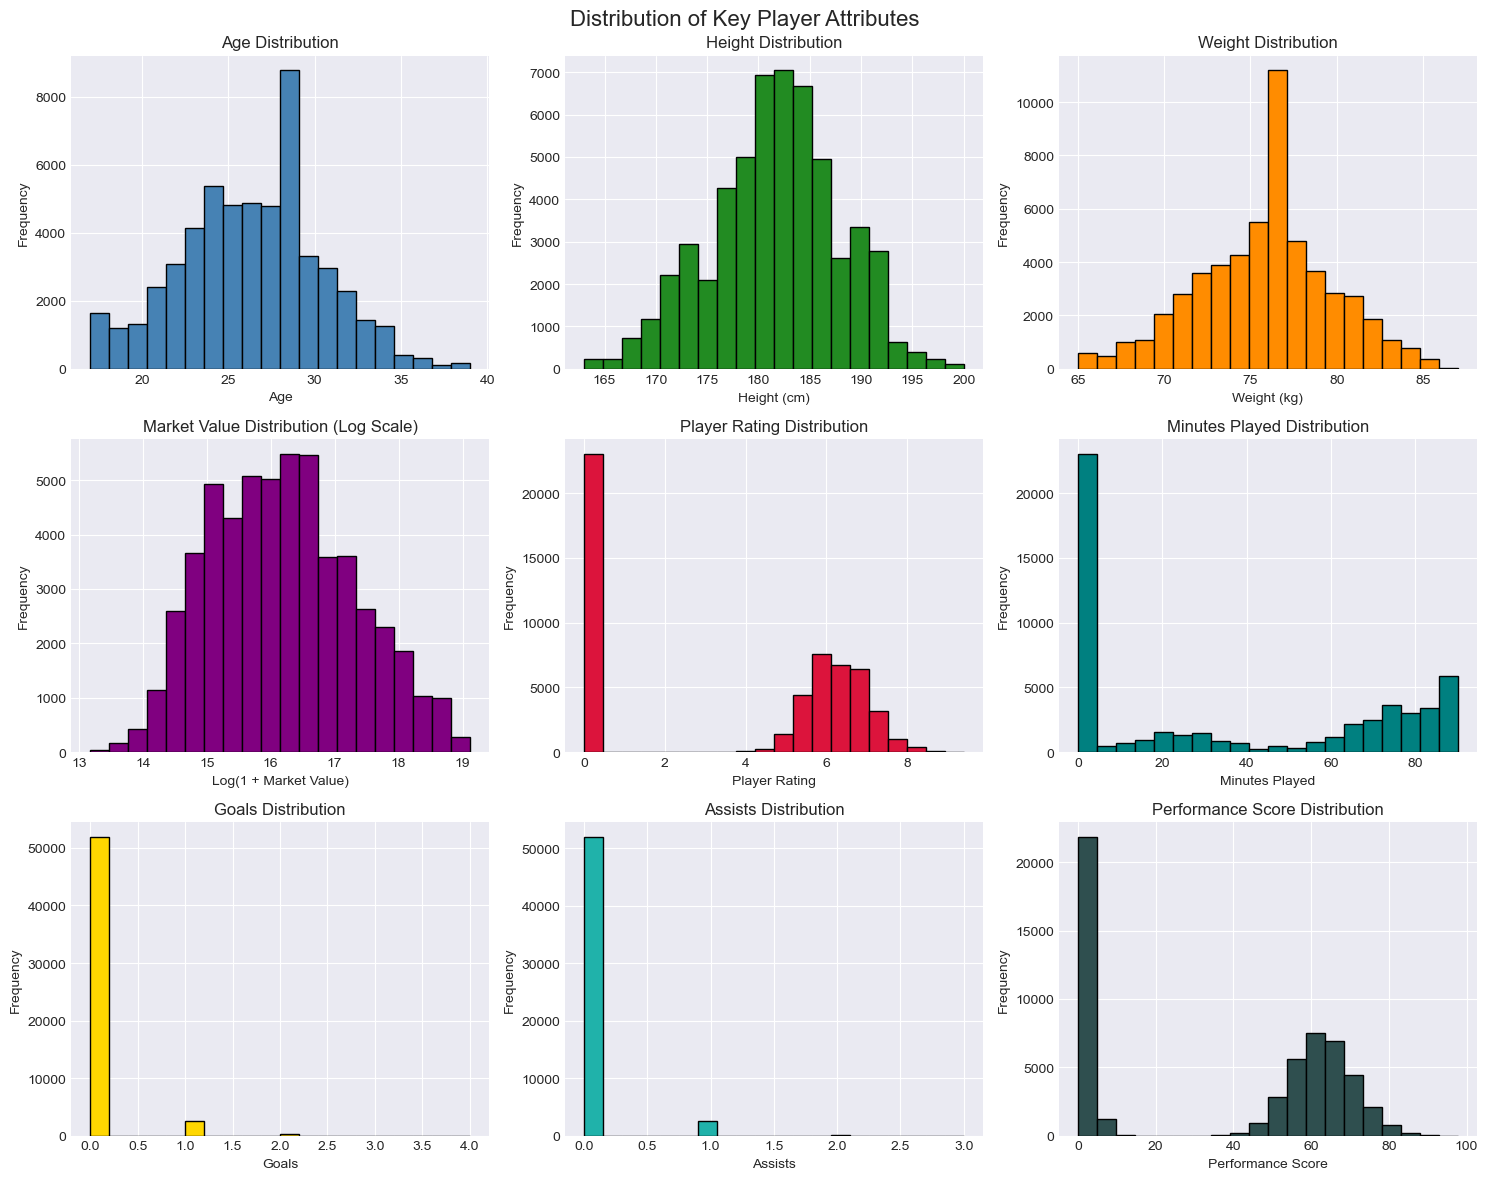

In [85]:
# Create a figure with subplots for key distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of Key Player Attributes', fontsize=16)

# Age Distribution
axes[0, 0].hist(df['age'], bins=20, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Height Distribution
axes[0, 1].hist(df['height_cm'], bins=20, edgecolor='black', color='forestgreen')
axes[0, 1].set_title('Height Distribution')
axes[0, 1].set_xlabel('Height (cm)')
axes[0, 1].set_ylabel('Frequency')

# Weight Distribution
axes[0, 2].hist(df['weight_kg'], bins=20, edgecolor='black', color='darkorange')
axes[0, 2].set_title('Weight Distribution')
axes[0, 2].set_xlabel('Weight (kg)')
axes[0, 2].set_ylabel('Frequency')

# Market Value Distribution (log scale)
axes[1, 0].hist(np.log1p(df['market_value_eur']), bins=20, edgecolor='black', color='purple')
axes[1, 0].set_title('Market Value Distribution (Log Scale)')
axes[1, 0].set_xlabel('Log(1 + Market Value)')
axes[1, 0].set_ylabel('Frequency')

# Player Rating Distribution
axes[1, 1].hist(df['player_rating'], bins=20, edgecolor='black', color='crimson')
axes[1, 1].set_title('Player Rating Distribution')
axes[1, 1].set_xlabel('Player Rating')
axes[1, 1].set_ylabel('Frequency')

# Minutes Played Distribution
axes[1, 2].hist(df['minutes_played'], bins=20, edgecolor='black', color='teal')
axes[1, 2].set_title('Minutes Played Distribution')
axes[1, 2].set_xlabel('Minutes Played')
axes[1, 2].set_ylabel('Frequency')

# Goals Distribution
axes[2, 0].hist(df['goals'], bins=20, edgecolor='black', color='gold')
axes[2, 0].set_title('Goals Distribution')
axes[2, 0].set_xlabel('Goals')
axes[2, 0].set_ylabel('Frequency')

# Assists Distribution
axes[2, 1].hist(df['assists'], bins=20, edgecolor='black', color='lightseagreen')
axes[2, 1].set_title('Assists Distribution')
axes[2, 1].set_xlabel('Assists')
axes[2, 1].set_ylabel('Frequency')

# Performance Score Distribution
axes[2, 2].hist(df['performance_score'], bins=20, edgecolor='black', color='darkslategray')
axes[2, 2].set_title('Performance Score Distribution')
axes[2, 2].set_xlabel('Performance Score')
axes[2, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_univariate_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

2.3 Categorical Analysis

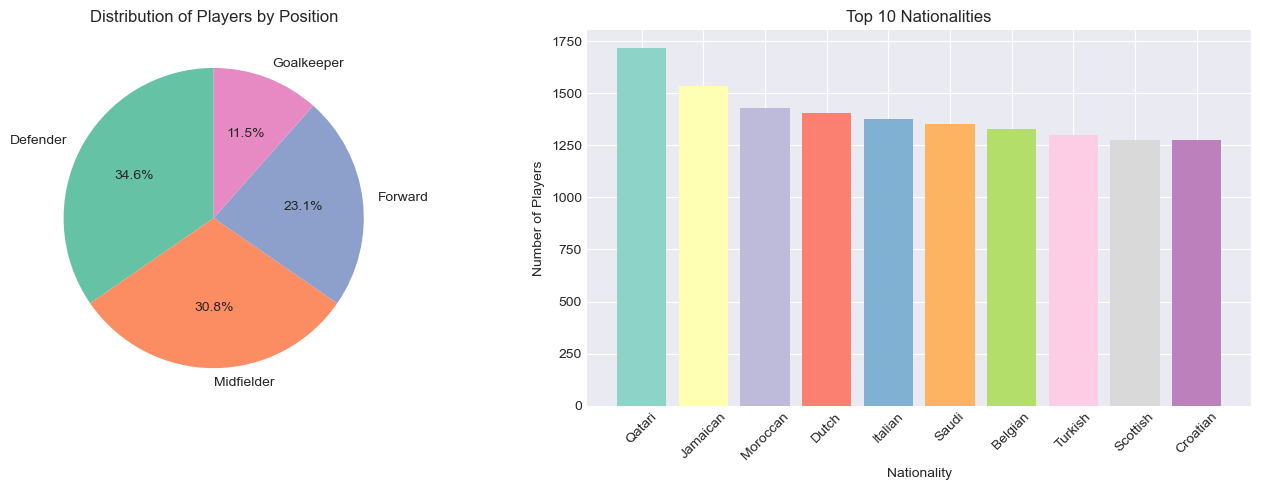

In [86]:
# Position Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

position_counts = df['position_category'].value_counts()
axes[0].pie(position_counts.values, labels=position_counts.index, 
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
axes[0].set_title('Distribution of Players by Position')

# Nationality distribution
nationality_counts = df['nationality'].value_counts().head(10)
axes[1].bar(nationality_counts.index, nationality_counts.values, 
            color=sns.color_palette("Set3", 10))
axes[1].set_title('Top 10 Nationalities')
axes[1].set_xlabel('Nationality')
axes[1].set_ylabel('Number of Players')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

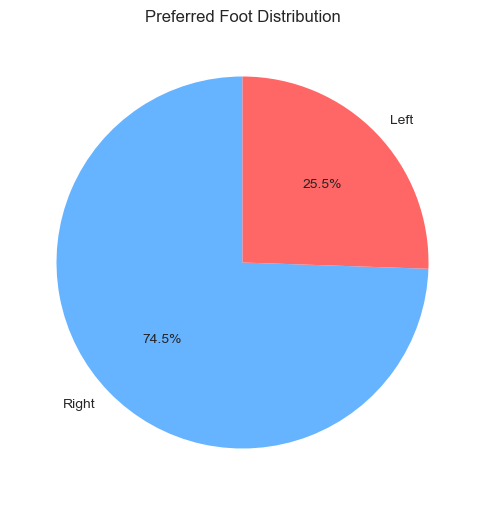

In [87]:
foot_counts = df['preferred_foot'].value_counts()
plt.figure(figsize=(6, 24))
plt.pie(foot_counts.values, labels=foot_counts.index, 
        autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff6666'])
plt.title('Preferred Foot Distribution')
plt.savefig('eda_foot_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

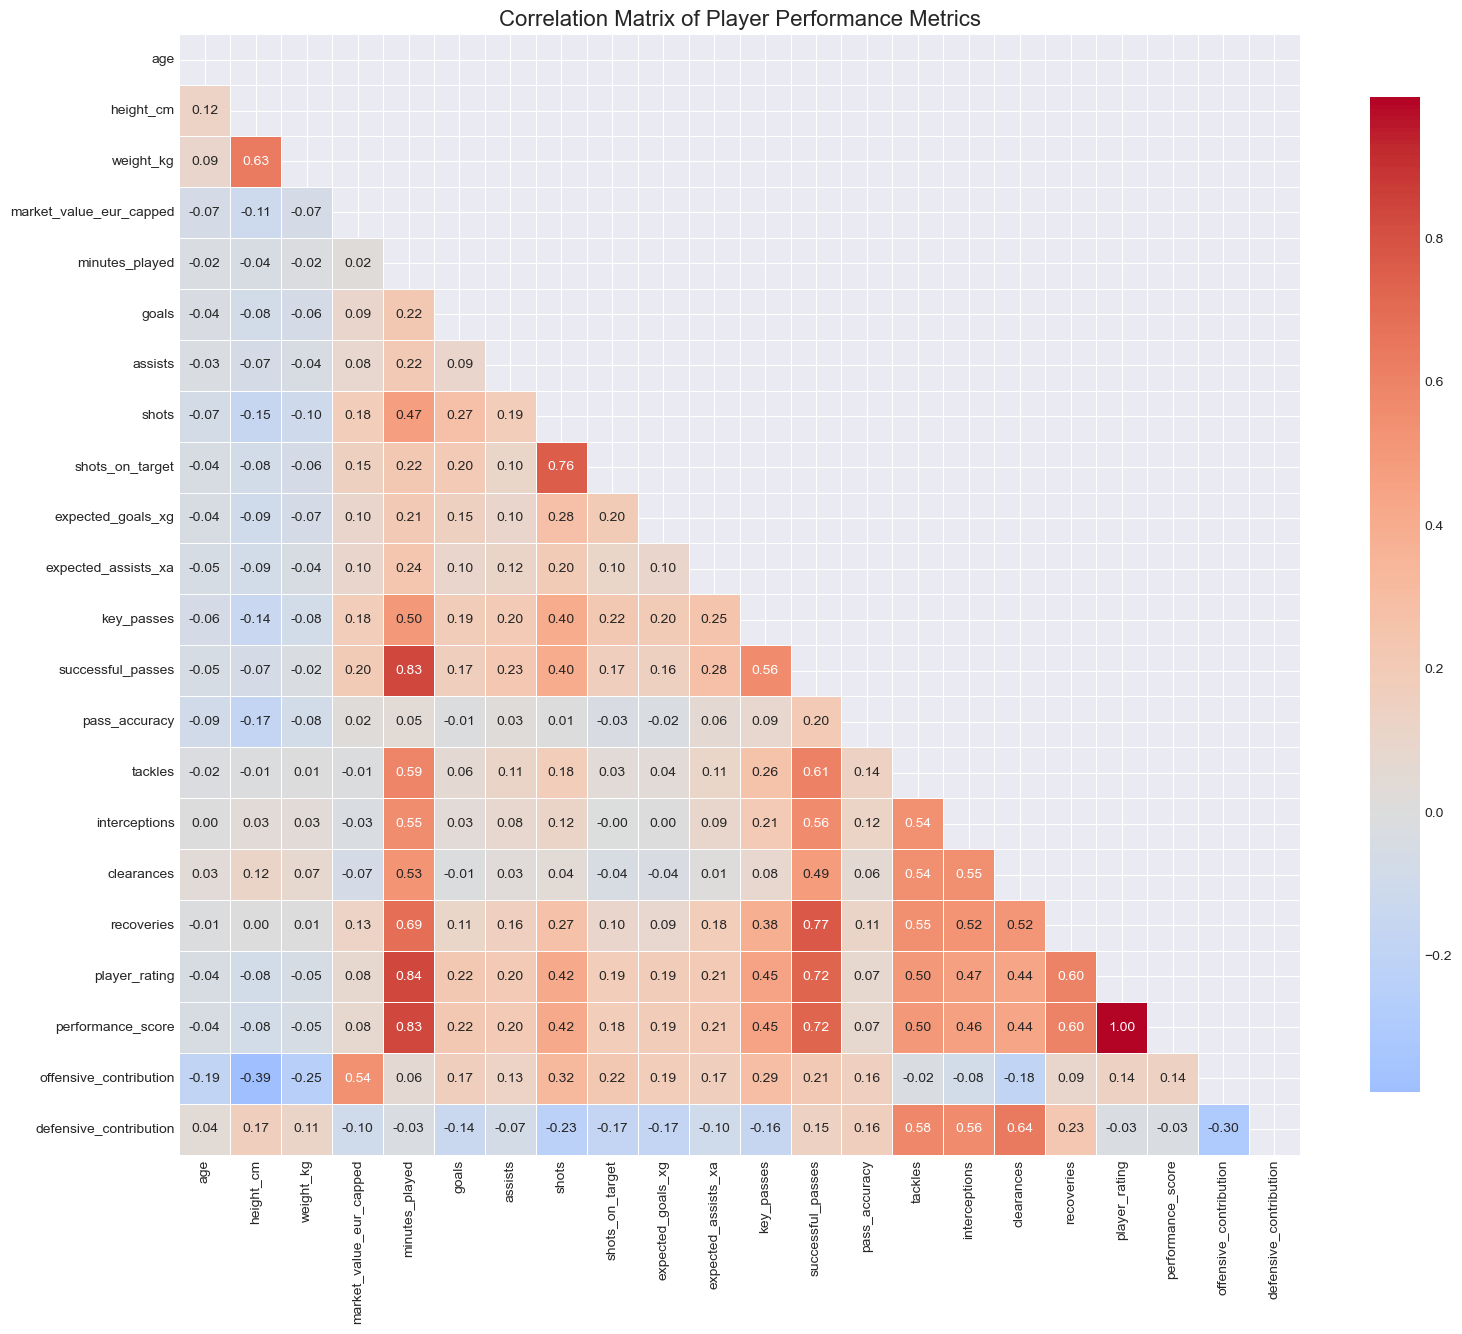

In [88]:
# Correlation Analysis
numerical_features = ['age', 'height_cm', 'weight_kg', 'market_value_eur_capped',
                      'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target',
                      'expected_goals_xg', 'expected_assists_xa', 'key_passes',
                      'successful_passes', 'pass_accuracy', 'tackles', 'interceptions',
                      'clearances', 'recoveries', 'player_rating', 'performance_score',
                      'offensive_contribution', 'defensive_contribution']

corr_matrix = df[numerical_features].corr()

# Create correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Player Performance Metrics', fontsize=16)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [89]:
# Correlation Analysis
print("\nKey Correlations with Player Rating:")
rating_corr = corr_matrix['player_rating'].sort_values(ascending=False)
print(rating_corr[1:6])

print("\nKey Correlations with Goals:")
goals_corr = corr_matrix['goals'].sort_values(ascending=False)
print(goals_corr[1:6])


Key Correlations with Player Rating:
performance_score    0.996610
minutes_played       0.837226
successful_passes    0.724937
recoveries           0.602474
tackles              0.501228
Name: player_rating, dtype: float64

Key Correlations with Goals:
shots                0.272756
minutes_played       0.219311
player_rating        0.217196
performance_score    0.216846
shots_on_target      0.200896
Name: goals, dtype: float64


2.5 Position-Based Analysis

Average Metrics by Position:
                     age  height_cm  weight_kg  player_rating  \
position_category                                               
Defender           26.67     183.56      76.41           3.79   
Forward            25.53     178.61      74.16           3.88   
Goalkeeper         28.67     189.11      78.69           2.07   
Midfielder         25.56     178.99      75.11           3.86   

                   performance_score  goals_per_90  assists_per_90  \
position_category                                                    
Defender                       38.36          0.04            0.06   
Forward                        39.29          0.34            0.18   
Goalkeeper                     21.48          0.00             inf   
Midfielder                     39.02          0.12            0.19   

                   pass_accuracy  tackles  interceptions  
position_category                                         
Defender               820244.44     1.31

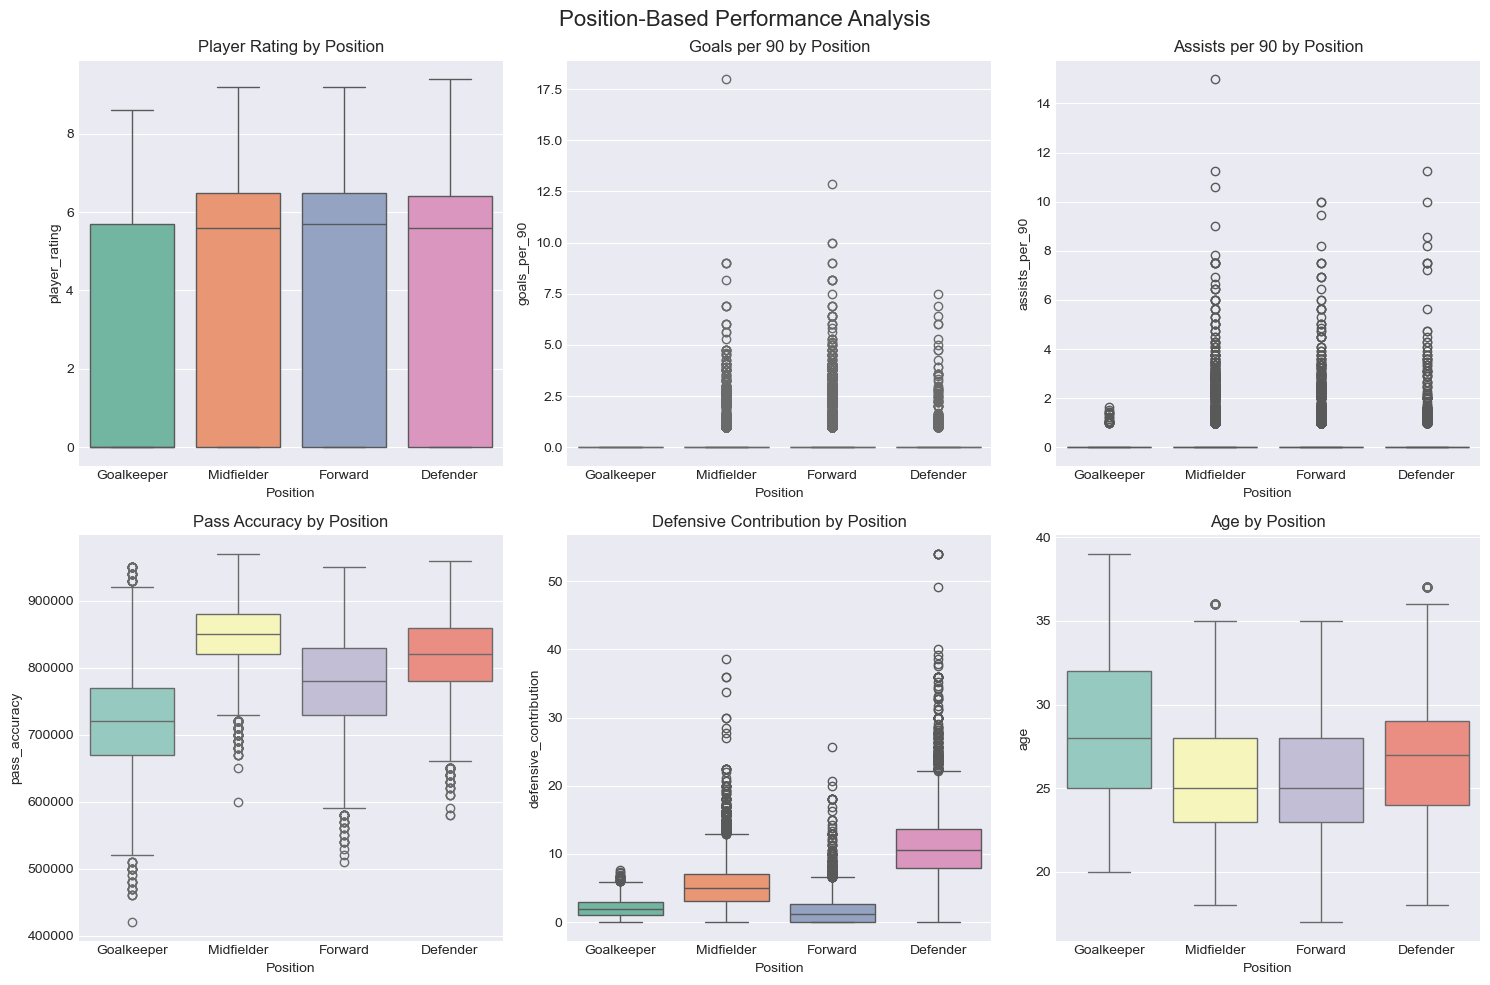

In [90]:
# Compare metrics across positions
position_comparison = df.groupby('position_category').agg({
    'age': 'mean',
    'height_cm': 'mean',
    'weight_kg': 'mean',
    'player_rating': 'mean',
    'performance_score': 'mean',
    'goals_per_90': 'mean',
    'assists_per_90': 'mean',
    'pass_accuracy': 'mean',
    'tackles': 'mean',
    'interceptions': 'mean'
}).round(2)

print("Average Metrics by Position:")
print(position_comparison)

# Visualize position differences
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Position-Based Performance Analysis', fontsize=16)

# Player Rating by Position
sns.boxplot(data=df, x='position_category', y='player_rating', 
            ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Player Rating by Position')
axes[0, 0].set_xlabel('Position')

# Goals per 90 by Position
sns.boxplot(data=df[df['minutes_played'] > 0], x='position_category', 
            y='goals_per_90', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Goals per 90 by Position')
axes[0, 1].set_xlabel('Position')

# Assists per 90 by Position
sns.boxplot(data=df[df['minutes_played'] > 0], x='position_category', 
            y='assists_per_90', ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Assists per 90 by Position')
axes[0, 2].set_xlabel('Position')

# Pass Accuracy by Position
sns.boxplot(data=df, x='position_category', y='pass_accuracy', 
            ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Pass Accuracy by Position')
axes[1, 0].set_xlabel('Position')

# Defensive Contribution by Position
sns.boxplot(data=df, x='position_category', y='defensive_contribution', 
            ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Defensive Contribution by Position')
axes[1, 1].set_xlabel('Position')

# Age by Position
sns.boxplot(data=df, x='position_category', y='age', 
            ax=axes[1, 2], palette='Set3')
axes[1, 2].set_title('Age by Position')
axes[1, 2].set_xlabel('Position')

plt.tight_layout()
plt.savefig('eda_position_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

2.6 Age and Performance Analysis

In [91]:
# Create age groups for analysis
bins = [17, 22, 27, 32, 37, 42]
labels = ['18-22', '23-27', '28-32', '33-37', '38+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Age group analysis
age_group_stats = df.groupby('age_group').agg({
    'player_rating': 'mean',
    'performance_score': 'mean',
    'minutes_played': 'mean',
    'goals': 'mean',
    'assists': 'mean'
}).round(2)

print("Performance by Age Group:")
print(age_group_stats)

Performance by Age Group:
           player_rating  performance_score  minutes_played  goals  assists
age_group                                                                  
18-22               3.80              38.49           37.49   0.07     0.07
23-27               3.70              37.51           36.57   0.06     0.05
28-32               3.59              36.35           35.90   0.05     0.05
33-37               3.40              34.57           34.80   0.04     0.05
38+                 2.22              23.03           25.96   0.00     0.02


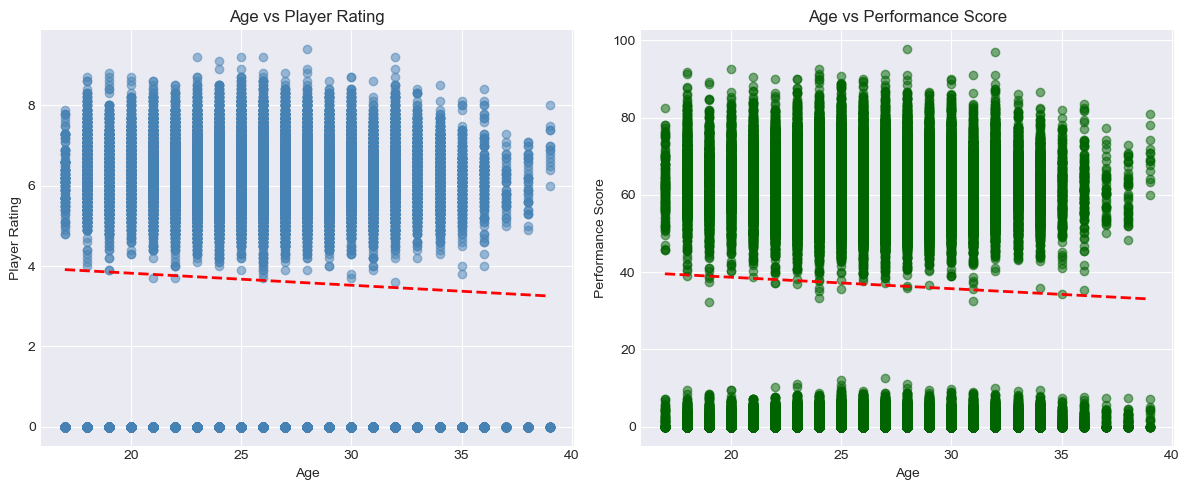

In [92]:
# Visualize age vs performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age vs Player
axes[0].scatter(df['age'], df['player_rating'], alpha=0.5, color='steelblue')
z = np.polyfit(df['age'], df['player_rating'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['age']), p(sorted(df['age'])), "r--", linewidth=2)
axes[0].set_title('Age vs Player Rating')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Player Rating')

# Age vs Performance
axes[1].scatter(df['age'], df['performance_score'], alpha=0.5, color='darkgreen')
z = np.polyfit(df['age'], df['performance_score'], 1)
p = np.poly1d(z)
axes[1].plot(sorted(df['age']), p(sorted(df['age'])), "r--", linewidth=2)
axes[1].set_title('Age vs Performance Score')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Performance Score')

plt.tight_layout()
plt.savefig('eda_age_performance.png', dpi=300, bbox_inches='tight')
plt.show()

2.7 Market Value Analysis

In [93]:
# Top 10 most valuable players
top_values = df.nlargest(10, 'market_value_eur')[['player_name', 'nationality', 'position', 'market_value_eur','player_rating']]
print("Top 10 Most Valuable Players:")
print(top_values)

Top 10 Most Valuable Players:
           player_name nationality    position  market_value_eur  \
174    Houssem Mokrani    Algerian  Midfielder         200000000   
566    Houssem Mokrani    Algerian  Midfielder         200000000   
1295  Saleh Al-Qahtani       Saudi     Forward         200000000   
1495      Romelu Onana     Belgian  Midfielder         200000000   
1629  Saleh Al-Qahtani       Saudi     Forward         200000000   
1956  Saleh Al-Qahtani       Saudi     Forward         200000000   
2041   Houssem Mokrani    Algerian  Midfielder         200000000   
2123  Saleh Al-Qahtani       Saudi     Forward         200000000   
2308   Houssem Mokrani    Algerian  Midfielder         200000000   
2561      Romelu Onana     Belgian  Midfielder         200000000   

      player_rating  
174             0.0  
566             0.0  
1295            0.0  
1495            8.2  
1629            0.0  
1956            7.2  
2041            7.7  
2123            0.0  
2308            0.0  
2

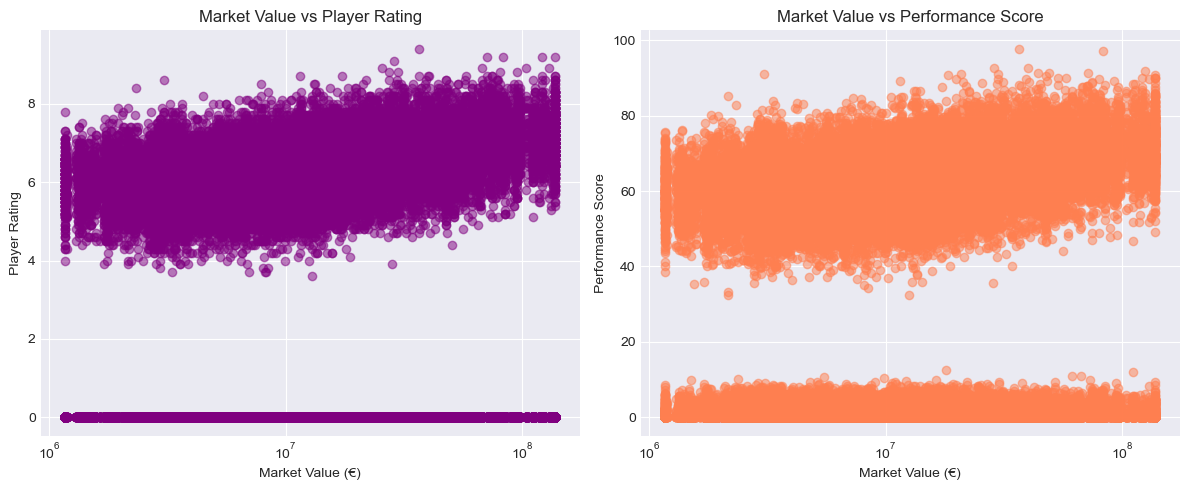

In [94]:
# Market Value vs Performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Market Value vs Player Rating
axes[0].scatter(df['market_value_eur_capped'], df['player_rating'], 
                alpha=0.5, color='purple')
axes[0].set_title('Market Value vs Player Rating')
axes[0].set_xlabel('Market Value (€)')
axes[0].set_ylabel('Player Rating')
axes[0].set_xscale('log')

# Market Value vs Performance Score
axes[1].scatter(df['market_value_eur_capped'], df['performance_score'], 
                alpha=0.5, color='coral')
axes[1].set_title('Market Value vs Performance Score')
axes[1].set_xlabel('Market Value (€)')
axes[1].set_ylabel('Performance Score')
axes[1].set_xscale('log')

plt.tight_layout()
plt.savefig('eda_market_value.png', dpi=300, bbox_inches='tight')
plt.show()

In [95]:
position_value = df.groupby('position_category')['market_value_eur'].mean().sort_values(ascending=False)
print("\nAverage Market Value by Position (€):")
print(position_value.round(2))


Average Market Value by Position (€):
position_category
Forward       27243386.00
Midfielder    22972887.84
Defender      15380287.61
Goalkeeper    12176579.57
Name: market_value_eur, dtype: float64


2.8 Shot Analysis

In [96]:
# Shot metrics by position
shot_stats = df.groupby('position_category').agg({
    'shots': 'mean',
    'shots_on_target': 'mean',
    'shot_conversion': 'mean',
    'goals': 'mean'
}).round(2)

print("Shot Statistics by Position:")
print(shot_stats)

Shot Statistics by Position:
                   shots  shots_on_target  shot_conversion  goals
position_category                                                
Defender            0.22             0.00             0.00   0.02
Forward             0.98             0.16             0.04   0.14
Goalkeeper          0.00             0.00             0.00   0.00
Midfielder          0.47             0.03             0.01   0.05


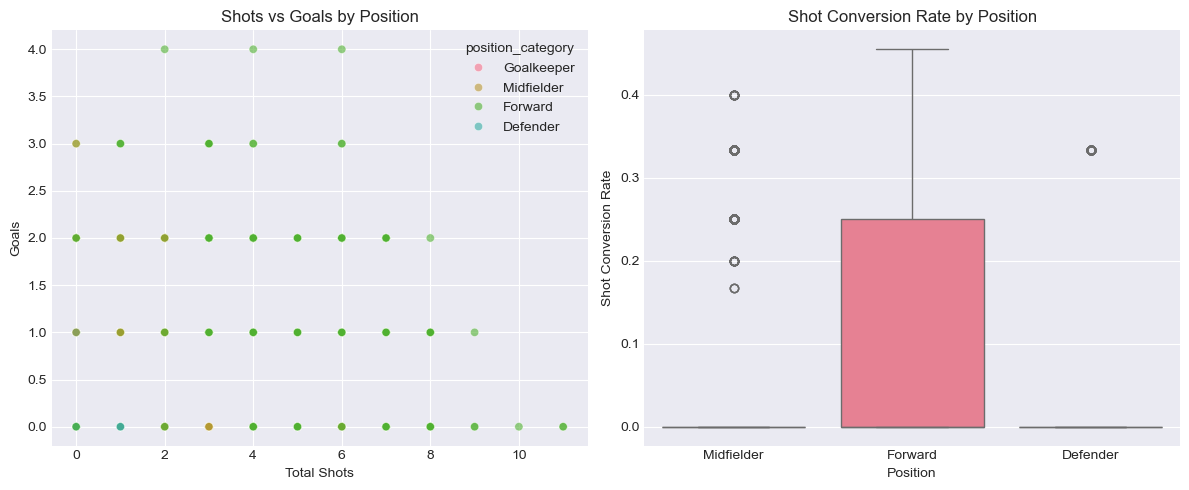

In [97]:
# Visualize shot efficiency
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Shots vs Goals
sns.scatterplot(data=df[df['minutes_played'] > 0], x='shots', y='goals', 
                hue='position_category', alpha=0.6, ax=axes[0])
axes[0].set_title('Shots vs Goals by Position')
axes[0].set_xlabel('Total Shots')
axes[0].set_ylabel('Goals')

# Conversion Rate by Position
sns.boxplot(data=df[df['shots'] > 0], x='position_category', 
            y='shot_conversion', ax=axes[1])
axes[1].set_title('Shot Conversion Rate by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Shot Conversion Rate')

plt.tight_layout()
plt.savefig('eda_shot_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

2.9 Passing Analysis

In [98]:
# Passing metrics by position
passing_stats = df.groupby('position_category').agg({
    'successful_passes': 'mean',
    'total_passes': 'mean',
    'pass_accuracy': 'mean',
    'key_passes': 'mean'
}).round(2)

print("Passing Statistics by Position:")
print(passing_stats)

Passing Statistics by Position:
                   successful_passes  total_passes  pass_accuracy  key_passes
position_category                                                            
Defender                       17.03         21.12      820244.44        0.23
Forward                        10.39         13.68      779776.19        0.59
Goalkeeper                      4.94          7.06      720850.79        0.09
Midfielder                     21.48         25.65      849505.36        0.80


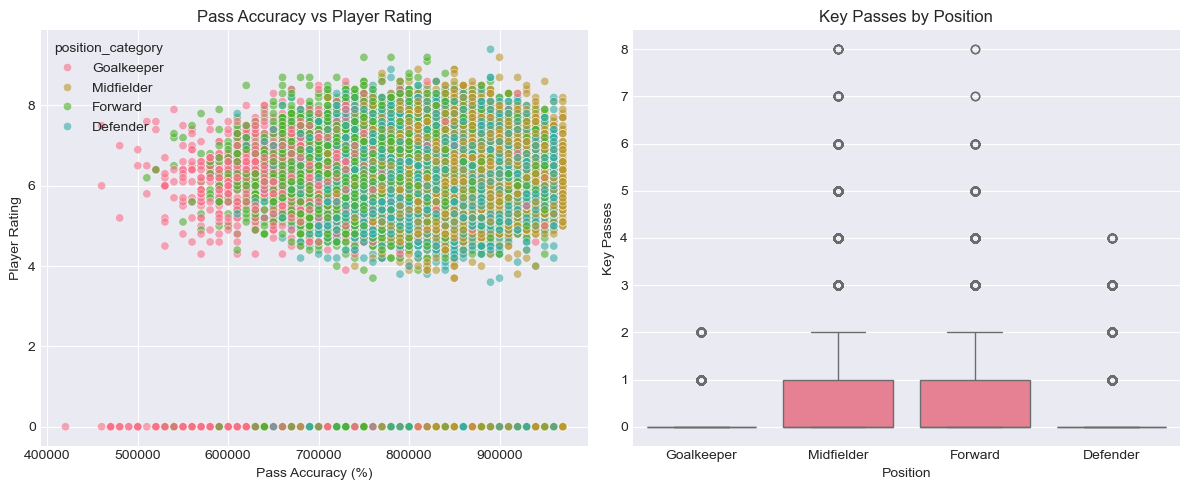

In [99]:
# Visualize passing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pass Accuracy vs Player Rating
sns.scatterplot(data=df, x='pass_accuracy', y='player_rating',hue='position_category', alpha=0.6, ax=axes[0])
axes[0].set_title('Pass Accuracy vs Player Rating')
axes[0].set_xlabel('Pass Accuracy (%)')
axes[0].set_ylabel('Player Rating')

# Passes by Position
sns.boxplot(data=df, x='position_category', y='key_passes', ax=axes[1])
axes[1].set_title('Key Passes by Position')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Key Passes')

plt.tight_layout()
plt.savefig('eda_passing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

2.10 Physical Attributes Analysis

In [100]:
# Physical attributes by position
physical_stats = df.groupby('position_category').agg({
    'height_cm': 'mean',
    'weight_kg': 'mean',
    'stamina_score': 'mean',
    'distance_covered_km': 'mean',
    'top_speed_kmh': 'mean'
}).round(2)

print("Physical Attributes by Position:")
print(physical_stats)


Physical Attributes by Position:
                   height_cm  weight_kg  stamina_score  distance_covered_km  \
position_category                                                             
Defender              183.56      76.41          82.17                 3.99   
Forward               178.61      74.16          82.37                 4.12   
Goalkeeper            189.11      78.69          78.84                 2.41   
Midfielder            178.99      75.11          82.36                 4.50   

                   top_speed_kmh  
position_category                 
Defender                   19.75  
Forward                    19.85  
Goalkeeper                  9.68  
Midfielder                 19.86  


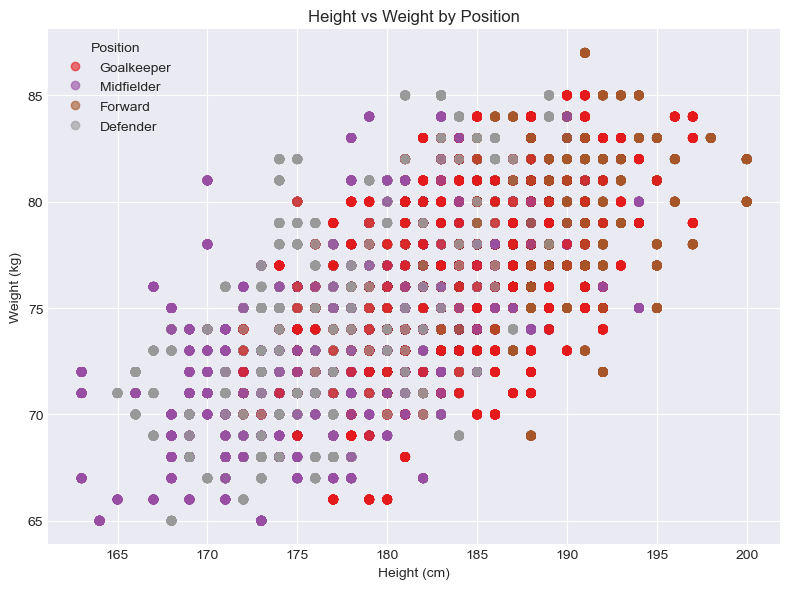

In [101]:
# Height vs Weight
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['height_cm'], df['weight_kg'], 
                     c=df['position_category'].astype('category').cat.codes, 
                     alpha=0.6, cmap='Set1')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Height vs Weight by Position')
handles = scatter.legend_elements()[0]
labels = df['position_category'].unique()
plt.legend(handles, labels, title='Position')

plt.tight_layout()
plt.savefig('eda_physical_attributes.png', dpi=300, bbox_inches='tight')
plt.show()

2.11 Nationality Performance Comparison

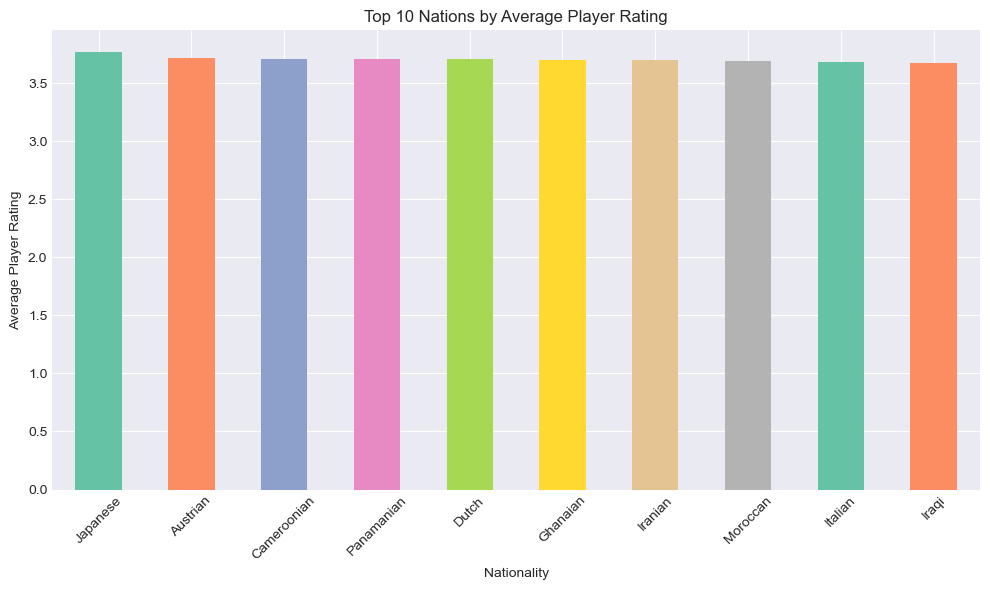

National Performance Summary (Top 10):
             player_rating  performance_score  goals  assists
nationality                                                  
Japanese              3.76              38.25     49       54
Panamanian            3.71              37.51     90       81
Cameroonian           3.71              37.60     88       66
Dutch                 3.71              37.58     94       85
Austrian              3.71              37.46     54       44
Ghanaian              3.70              37.49     75       65
Iranian               3.70              37.44     72       70
Moroccan              3.69              37.39     68       61
Italian               3.68              37.35     64       76
Iraqi                 3.68              37.31     62       56


In [102]:
# Top 10 nations by average player rating
nation_rating = df.groupby('nationality')['player_rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
nation_rating.plot(kind='bar', color=sns.color_palette("Set2", 10))
plt.title('Top 10 Nations by Average Player Rating')
plt.xlabel('Nationality')
plt.ylabel('Average Player Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_nationality_rating.png', dpi=300, bbox_inches='tight')
plt.show()

# Average performance by nation
nation_performance = df.groupby('nationality').agg({
    'player_rating': 'mean',
    'performance_score': 'mean',
    'goals': 'sum',
    'assists': 'sum'
}).round(2).sort_values('player_rating', ascending=False)

print("National Performance Summary (Top 10):")
print(nation_performance.head(10))

2.12 Temporal Analysis

In [103]:
# Match day analysis
match_days = df.groupby('match_date').agg({
    'player_rating': 'mean',
    'goals': 'sum',
    'performance_score': 'mean'
}).round(2)

print("Match Day Performance Summary:")
match_days

Match Day Performance Summary:


,player_rating,goals,performance_score
match_date,,,
2026-06-11,3.58,36,36.31
2026-06-12,3.64,70,36.92
2026-06-13,3.69,42,37.58
2026-06-14,3.60,48,36.40
2026-06-15,3.59,50,36.52
2026-06-16,3.60,79,36.48
2026-06-17,3.65,56,36.87
2026-06-18,3.56,51,36.10
2026-06-19,3.63,67,36.73


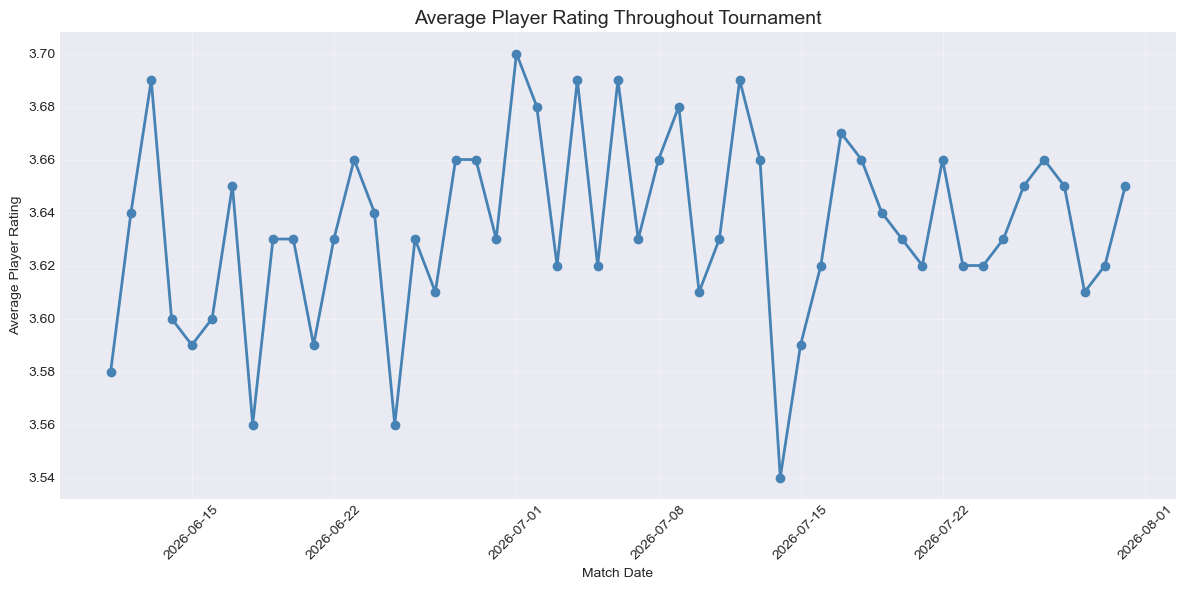

In [104]:
# Visualize performance over tournament
plt.figure(figsize=(12, 6))
plt.plot(match_days.index, match_days['player_rating'], marker='o', 
         color='steelblue', linewidth=2)
plt.title('Average Player Rating Throughout Tournament', fontsize=14)
plt.xlabel('Match Date')
plt.ylabel('Average Player Rating')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_temporal_performance.png', dpi=300, bbox_inches='tight')
plt.show()

3. Key Insights and Patterns

In [105]:
# Identify top performers in key categories
top_goals = df.nlargest(5, 'goals')[['player_name', 'nationality', 'position', 'goals', 'shots', 'player_rating']]
top_assists = df.nlargest(5, 'assists')[['player_name', 'nationality', 'position', 'assists', 'key_passes', 'player_rating']]
top_rating = df.nlargest(5, 'player_rating')[['player_name', 'nationality', 'position', 'player_rating', 'performance_score']]

print("Top 5 Goal Scorers:")
print(top_goals)

print("\nTop 5 Assists Providers:")
print(top_assists)

print("\nTop 5 Highest Rated Players:")
print(top_rating)

Top 5 Goal Scorers:
            player_name  nationality position  goals  shots  player_rating
18259    Tajon Buchanan     Canadian  Forward      4      2            7.2
38411  Memphis Zerrouki        Dutch  Forward      4      4            9.2
49350     Samuel Olinga  Cameroonian  Forward      4      6            8.5
3513       Saman Azmoun      Iranian  Forward      3      1            7.9
7134       Aaron Wright   Australian  Forward      3      0            6.3

Top 5 Assists Providers:
            player_name nationality    position  assists  key_passes  \
940       Felix Caicedo  Ecuadorian  Midfielder        3           2   
1149   Safaa Al-Khafaji       Iraqi  Midfielder        3           2   
9316     Trezeguet Said    Egyptian  Midfielder        3           0   
16489         Dani Gavi     Spanish  Midfielder        3           1   
20784     Mehdi Hazbavi     Iranian     Forward        3           1   

       player_rating  
940              7.4  
1149             6.4  
93

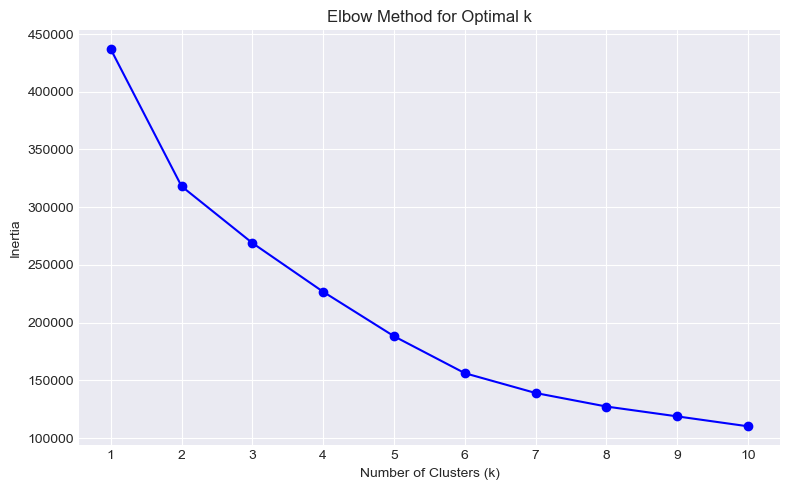

In [106]:
# Perform K-means clustering
cluster_features = ['goals', 'assists', 'shots_on_target', 'successful_passes','tackles', 'interceptions', 'player_rating', 'pass_accuracy']

# Prepare data for clustering
cluster_data = df[cluster_features].fillna(0)
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# elbow method
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_data_scaled)
    inertias.append(kmeans.inertia_)

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.tight_layout()
plt.savefig('eda_kmeans_elbow.png', dpi=300, bbox_inches='tight')
plt.show()

In [107]:
# Apply K-means with k=3 (based on elbow)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_data_scaled)


cluster_summary = df.groupby('cluster').agg({
    'player_rating': 'mean',
    'performance_score': 'mean',
    'goals': 'mean',
    'assists': 'mean',
    'pass_accuracy': 'mean',
    'tackles': 'mean',
    'position_category': lambda x: x.value_counts().index[0]
}).round(2)

print("Cluster Characteristics:")
print(cluster_summary)

Cluster Characteristics:
         player_rating  performance_score  goals  assists  pass_accuracy  \
cluster                                                                    
0                 1.80              18.81    0.0     0.00      795787.05   
1                 6.31              63.09    0.0     0.12      830166.95   
2                 6.71              67.08    1.1     0.15      806663.02   

         tackles position_category  
cluster                             
0           0.07          Defender  
1           1.99          Defender  
2           1.18           Forward  


In [108]:
# Generate comprehensive summary report
insights = {
    "Dataset Overview": {
        "Total Players": len(df),
        "Total Matches": df['match_id'].nunique(),
        "Unique Nationalities": df['nationality'].nunique(),
        "Unique Positions": df['position'].nunique()
    },
    "Performance Highlights": {
        "Highest Rated Player": df.loc[df['player_rating'].idxmax(), 'player_name'],
        "Top Goal Scorer": df.loc[df['goals'].idxmax(), 'player_name'],
        "Top Assists Provider": df.loc[df['assists'].idxmax(), 'player_name'],
        "Best Performance Score": df.loc[df['performance_score'].idxmax(), 'player_name']
    },
    "Position Insights": {
        "Most Common Position": df['position_category'].mode()[0],
        "Best Rated Position": df.groupby('position_category')['player_rating'].mean().idxmax(),
        "Best Scoring Position": df.groupby('position_category')['goals'].mean().idxmax()
    },
    "Age Insights": {
        "Average Age": df['age'].mean(),
        "Youngest Player": df.loc[df['age'].idxmin(), 'player_name'],
        "Oldest Player": df.loc[df['age'].idxmax(), 'player_name'],
        "Peak Performance Age": df.groupby('age')['player_rating'].mean().idxmax()
    }
}

# Print the report
print("=" * 50)
print("FIFA WORLD CUP 2026 - DATA INSIGHTS REPORT")
print("=" * 50)

for category, data in insights.items():
    print(f"\n{category}:")
    for key, value in data.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")

FIFA WORLD CUP 2026 - DATA INSIGHTS REPORT

Dataset Overview:
  Total Players: 54600
  Total Matches: 1050
  Unique Nationalities: 48
  Unique Positions: 4

Performance Highlights:
  Highest Rated Player: Mohamed Elneny
  Top Goal Scorer: Tajon Buchanan
  Top Assists Provider: Felix Caicedo
  Best Performance Score: Mohamed Elneny

Position Insights:
  Most Common Position: Defender
  Best Rated Position: Forward
  Best Scoring Position: Forward

Age Insights:
  Average Age: 26.30
  Youngest Player: Nayef Chibi
  Oldest Player: Mykhailo Sudakov
  Peak Performance Age: 18


In [109]:
# Generate recommendations based on findings
recommendations = {
    "Team Selection": [
        "Balance experience and youth: Peak performance occurs around age 25-27",
        "Consider position-specific strengths: Forwards excel in goal scoring, midfielders in playmaking, defenders in defensive actions",
        "Market value correlates with performance: Higher value players generally perform better"
    ],
    "Player Development": [
        "Focus on shot conversion: Many players take many shots but convert few",
        "Improve passing accuracy: Higher pass accuracy correlates with better ratings",
        "Physical attributes matter: Height and weight vary by position"
    ],
    "Tactical Insights": [
        "Utilize players based on position strengths: Forwards for attacking, midfielders for creativity, defenders for stability",
        "Age diversity: Mix experienced players with younger talent",
        "League experience matters: Players from top clubs tend to perform better"
    ]
}

print("\n" + "=" * 30)
print("KEY RECOMMENDATIONS")
print("=" * 30)

for category, recs in recommendations.items():
    print(f"\n{category}:")
    for rec in recs:
        print(f"  • {rec}")


KEY RECOMMENDATIONS

Team Selection:
  • Balance experience and youth: Peak performance occurs around age 25-27
  • Consider position-specific strengths: Forwards excel in goal scoring, midfielders in playmaking, defenders in defensive actions
  • Market value correlates with performance: Higher value players generally perform better

Player Development:
  • Focus on shot conversion: Many players take many shots but convert few
  • Improve passing accuracy: Higher pass accuracy correlates with better ratings
  • Physical attributes matter: Height and weight vary by position

Tactical Insights:
  • Utilize players based on position strengths: Forwards for attacking, midfielders for creativity, defenders for stability
  • Age diversity: Mix experienced players with younger talent
  • League experience matters: Players from top clubs tend to perform better


In [110]:
# Create summary DataFrames
summary_data = {
    'Player_Performance': df[['player_name', 'nationality', 'position', 'age', 
                              'player_rating', 'performance_score', 
                              'goals', 'assists', 'market_value_eur']].head(20),
    'Position_Stats': position_stats.reset_index(),
    'Age_Group_Stats': age_group_stats.reset_index(),
    'National_Performance': nation_performance.reset_index()
}

# Save to CSV
for name, data in summary_data.items():
    data.to_csv(f'{name}.csv', index=False)
    print(f"✓ Exported {name}.csv")

print("\nAll export files have been created successfully!")

✓ Exported Player_Performance.csv
✓ Exported Position_Stats.csv
✓ Exported Age_Group_Stats.csv
✓ Exported National_Performance.csv

All export files have been created successfully!
